<a href="https://colab.research.google.com/github/AmitKunduA/Class_Assignment/blob/main/Decisiontree_KNN_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malicious URL Detection Using Machine Learning

**Dataset:** [Malicious URL Detection Dataset (Enhanced 2026)](https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026)

**Models:** Decision Tree · KNN · Logistic Regression | **Classes:** Benign · Defacement · Phishing · Malware

## 1. Imports & Setup


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2. Data Loading


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/python/dataset_with_all_features v2.csv')
print(f"Shape: {df.shape}")
df.head()

Mounted at /content/drive
Shape: (651191, 68)


,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,...,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,...,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15


## 3. Data Inspection


In [ ]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
print("\nLabels:\n", df['label'].value_counts().sort_index())
print("\nClass mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware")

Missing values per column:
 type         72
label        72
domain    12223
dtype: int64

Labels:
 label
0.0    428209
1.0     96457
2.0     93933
3.0     32520
Name: count, dtype: int64

Class mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware


## 4. Preprocessing & Train-Test Split


In [ ]:
df.drop(columns=['url','domain','type','Date_inspection'], inplace=True)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=['label'])
y = df['label']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20,stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 520952 | Test: 130239


## 5. Exploratory Data Analysis (EDA)


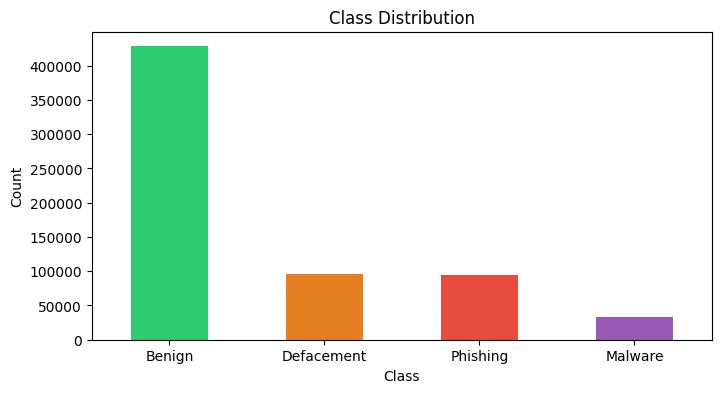

In [ ]:
labels = ['Benign', 'Defacement', 'Phishing', 'Malware']

counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()



## 6. Model Training & Baseline Results


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.9577  Precision = 0.9575 Recall = 0.9577 F1=0.9576
KNN (k=5): Acc=0.9642  Precision = 0.9636 Recall = 0.9642 F1=0.9635
Logistic Reg: Acc=0.9023  Precision = 0.8992 Recall = 0.9023 F1=0.8949


## 7. Decision Tree — Depth Tuning


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8747     0.8979  0.8747    0.8709
5            0.8947     0.9115  0.8947    0.8922
10           0.8931     0.9057  0.8931    0.8910
15           0.8784     0.8834  0.8784    0.8770
20           0.8532     0.8538  0.8532    0.8525
None         0.8124     0.8136  0.8124    0.8127


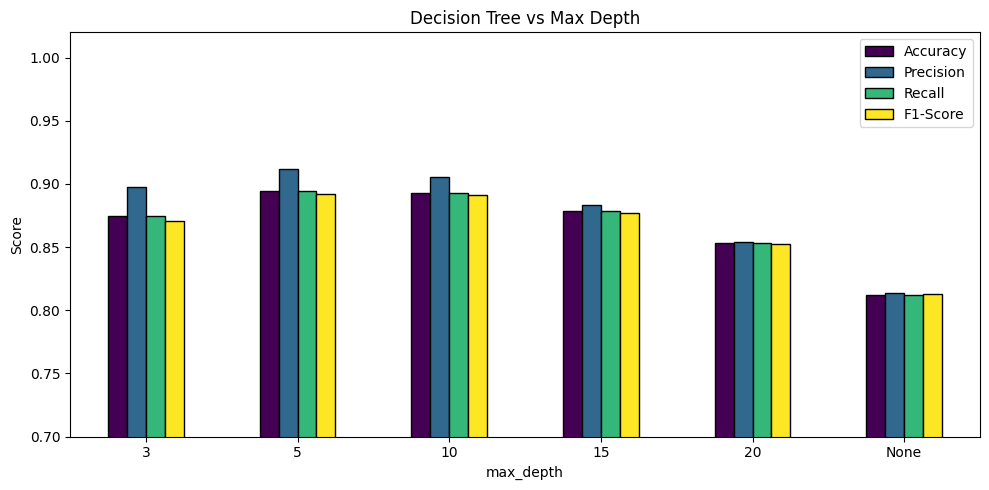

In [140]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'),
        'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth');
plt.ylabel('Score');
plt.ylim(0.7, 1.02);
plt.xticks(rotation=0)
plt.tight_layout();
plt.show()

## 8. Classification Reports


In [ ]:
target_names = ['Benign', 'Defacement', 'Phishing', 'Malware']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.9742    0.9757    0.9749     85657
  Defacement     0.9778    0.9813    0.9796     19291
    Phishing     0.8642    0.8565    0.8603     18787
     Malware     0.9469    0.9430    0.9449      6504

    accuracy                         0.9577    130239
   macro avg     0.9408    0.9391    0.9399    130239
weighted avg     0.9575    0.9577    0.9576    130239


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.9705    0.9890    0.9797     85657
  Defacement     0.9667    0.9873    0.9769     19291
    Phishing     0.9269    0.8393    0.8809     18787
     Malware     0.9692    0.9290    0.9487      6504

    accuracy                         0.9642    130239
   macro avg     0.9583    0.9361    0.9465    130239
weighted avg     0.9636    0.9642    0.9635    130239


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.9145    0.9802  

## 9. Confusion Matrices


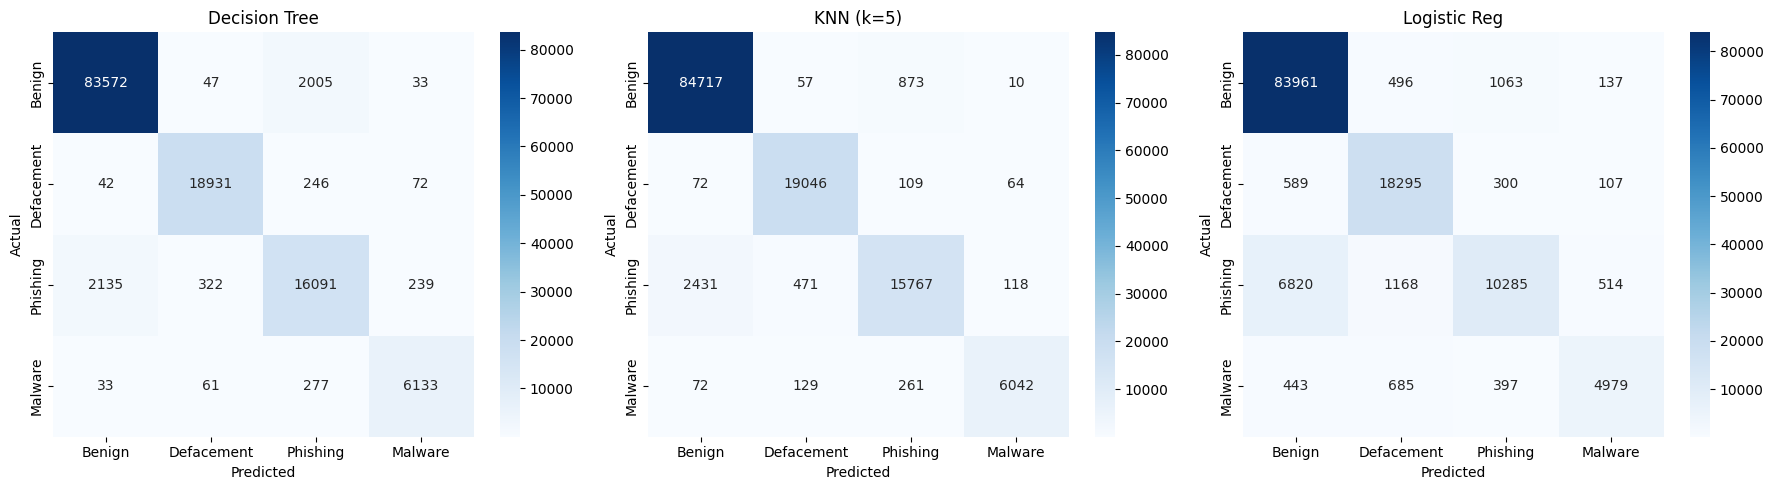

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name);
    ax.set_xlabel('Predicted');
    ax.set_ylabel('Actual');
plt.tight_layout();
plt.show()

## 10. Model Comparison


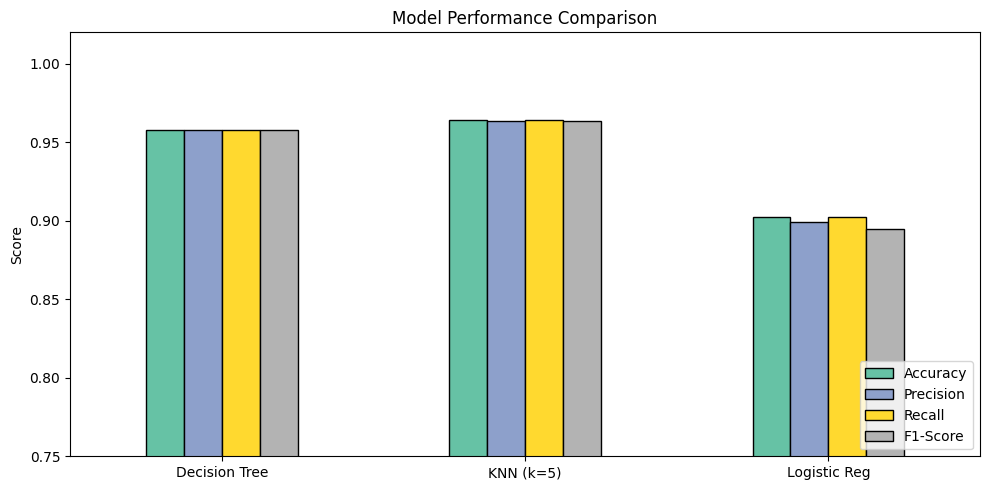


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.9577     0.9575  0.9577    0.9576
KNN (k=5)        0.9642     0.9636  0.9642    0.9635
Logistic Reg     0.9023     0.8992  0.9023    0.8949


In [ ]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.75, 1.02)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
print("\nSummary:\n", res_df.round(4))

#  Cybersecurity Intrusion Detection Dataset

**Dataset:** [Cybersecurity Intrusion Detection Dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset)

**Models:** Decision Tree · KNN · Logistic Regression |

Upload the dataset to your Google Drive under `datasets/` and complete the following tasks using the **same workflow** as this notebook.

| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.

## Load and Inspect

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [143]:
df = pd.read_csv('/content/drive/MyDrive/python/cybersecurity_intrusion_data.csv')
print(f'Shape:{df.shape}')
df.head()

Shape:(9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [144]:
df.isnull().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


In [145]:
df['attack_detected'].value_counts().sort_index()

,count
attack_detected,
0,5273
1,4264


## Preprocess

In [146]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type_encoded']= label_encoder.fit_transform(df['protocol_type'])
df['encryption_used_encoded']= label_encoder.fit_transform(df['encryption_used'])
df['browser_type_encoded']= label_encoder.fit_transform(df['browser_type'])

df.drop(columns=['session_id','protocol_type','encryption_used','browser_type'], inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)

X=df.drop(columns='attack_detected')
y=df['attack_detected']

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print(f'Train:{X_train.shape[0]} | Test:{X_test.shape[0]}')

Train:7629 | Test:1908


In [147]:
df.isnull().sum()

,0
network_packet_size,0
login_attempts,0
session_duration,0
ip_reputation_score,0
failed_logins,0
unusual_time_access,0
attack_detected,0
protocol_type_encoded,0
encryption_used_encoded,0
browser_type_encoded,0


## Exploratory Data Analysis (EDA)

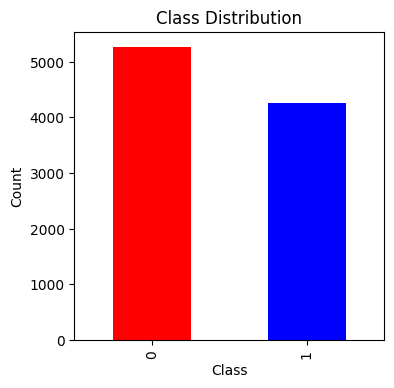

In [148]:
label=['attack_detected']

count= df['attack_detected'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4, 4))
count.plot.bar(ax=ax, color=['red','blue'])

ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()

 ## Model Training & Baseline Results

In [149]:
models= {
    'Decision Tree':DecisionTreeClassifier(random_state=30),
    'KNN':          KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg': LogisticRegression(max_iter=500, random_state=30)
}
results, predictions= {},{}

for name,m in models.items():
    m.fit(X_train,y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name]={
        'Accuracy':  accuracy_score(y_test,yp),
        'Precision': precision_score(y_test,yp,average='weighted'),
        'Recall'   : recall_score(y_test,yp,average='weighted'),
        'F1-score':  f1_score(y_test,yp,average='weighted')
     }
    print(f'{name}: acc={results[name]['Accuracy']:.4f} precision={results[name]['Precision']:.4f} recall={results[name]['Recall']:.4f} F1={results[name]['F1-score']:.4f}')

Decision Tree: acc=0.8108 precision=0.8125 recall=0.8108 F1=0.8112
KNN: acc=0.7993 precision=0.8093 recall=0.7993 F1=0.7945
Logistic Reg: acc=0.7411 precision=0.7403 recall=0.7411 F1=0.7401


## Decision Tree — Depth Tuning

           Accuracy  Precision  Recall  F1-score
max_depth                                       
3            0.8747     0.8979  0.8747    0.8709
5            0.8947     0.9115  0.8947    0.8922
10           0.8931     0.9057  0.8931    0.8910
15           0.8784     0.8834  0.8784    0.8770
20           0.8532     0.8538  0.8532    0.8525
None         0.8124     0.8136  0.8124    0.8127


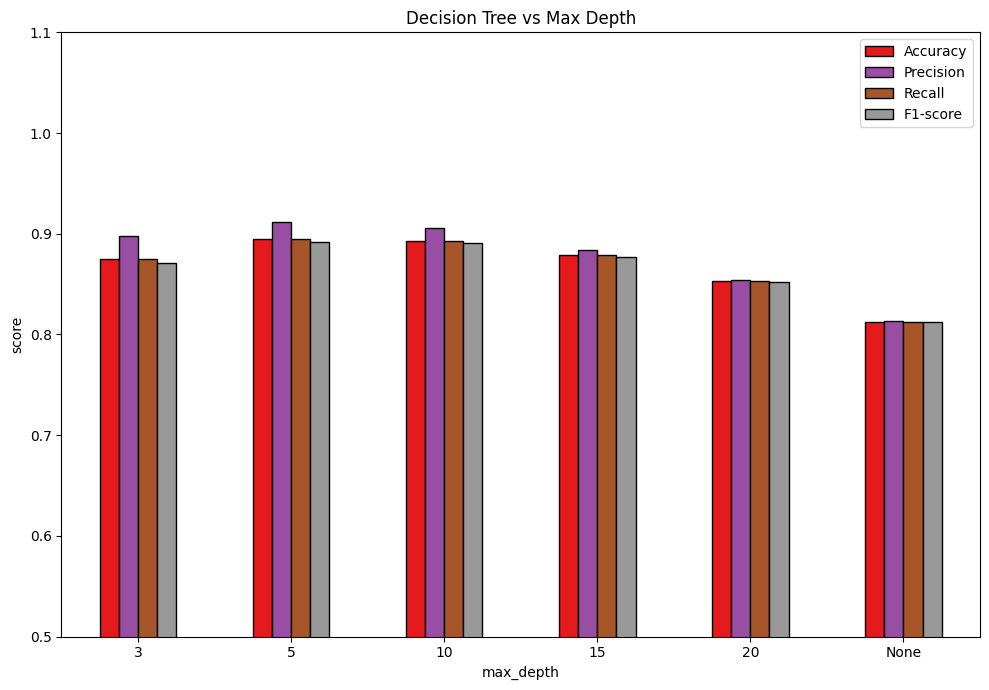

In [189]:
dt_results=[]
for d in [3, 5, 10, 15, 20, None]:
    dt=DecisionTreeClassifier(max_depth=d,random_state=20).fit(X_train,y_train)
    yp=dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy':  accuracy_score(y_test,yp),
        'Precision': precision_score(y_test,yp,average='weighted'),
        'Recall'   : recall_score(y_test,yp,average='weighted'),
        'F1-score':  f1_score(y_test,yp,average='weighted')})

dt_df=pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar',figsize=(10,7), colormap='Set1', edgecolor='black')
plt.title('Decision Tree vs Max Depth')
plt.ylabel('score')
plt.ylim(0.5,1.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Classification reports


In [166]:
target_name=['Normal','attack_detected']
for name, yp in predictions.items():
    print(f'\n{'='*20}\n{name}\n{'='*20}')
    print(classification_report(y_test, yp, digits=4))


Decision Tree
              precision    recall  f1-score   support

           0     0.8442    0.8066    0.8250      1055
           1     0.7733    0.8159    0.7941       853

    accuracy                         0.8108      1908
   macro avg     0.8088    0.8113    0.8095      1908
weighted avg     0.8125    0.8108    0.8112      1908


KNN
              precision    recall  f1-score   support

           0     0.7671    0.9147    0.8344      1055
           1     0.8615    0.6565    0.7452       853

    accuracy                         0.7993      1908
   macro avg     0.8143    0.7856    0.7898      1908
weighted avg     0.8093    0.7993    0.7945      1908


Logistic Reg
              precision    recall  f1-score   support

           0     0.7529    0.7915    0.7717      1055
           1     0.7247    0.6788    0.7010       853

    accuracy                         0.7411      1908
   macro avg     0.7388    0.7351    0.7363      1908
weighted avg     0.7403    0.7411    0.7

## Confusion Matrices


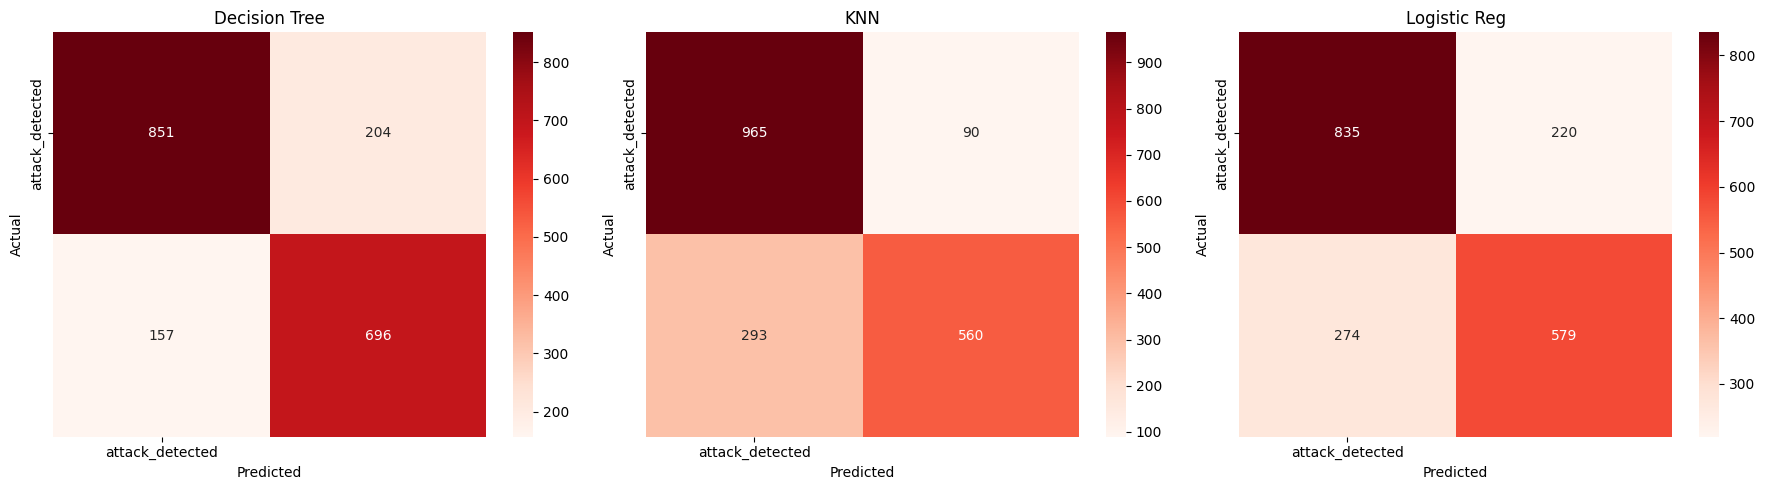

In [180]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test,yp), annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=target_names,yticklabels=target_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Model Comparison

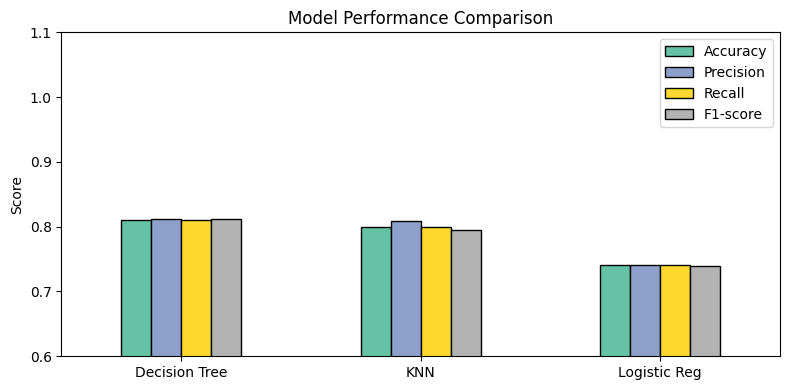


Summary
                Accuracy  Precision  Recall  F1-score
Decision Tree    0.8108     0.8125  0.8108    0.8112
KNN              0.7993     0.8093  0.7993    0.7945
Logistic Reg     0.7411     0.7403  0.7411    0.7401


In [187]:
re_df=pd.DataFrame(results).T
re_df.plot(kind='bar', figsize=(8,4), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.6,1.1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('\nSummary\n',re_df.round(4))